In [1]:
# importing packages
import finesse
import numpy as np
import matplotlib.pyplot as plt


In [51]:
# creating model
model = finesse.Model()
model.parse("""
    # Creating a laser, modulating its phase and amplitude (RFAM), splitting the beam, and sending it into the cavity: 
    l laser P=1
    mod pm1 100M 0.9 order=1 mod_type=pm phase=0.0
    mod am1 100M 0.1 order=1 mod_type=am phase=0.0

    bs bs1 R=0.5 T=0.5
    m inm R=0.9 T=0.1
    s scav portA=inm.p2 portB=outm.p1 L=0.5
    m outm R=0.9 T=0.1
    
    # Gluing elements together:
    # link(laser,pm1,am1,bs1,inm)

    # Creating photodetectors:
    pd pdtrans outm.p2.o
    pd pdrefl bs1.p4.o

    pd1 pdh node=bs1.p4.o f=pm1.f phase=0
    
""")
onetone = model.deepcopy()
onetone.parse("""
    link(laser,pm1,am1,bs1,inm)
""")

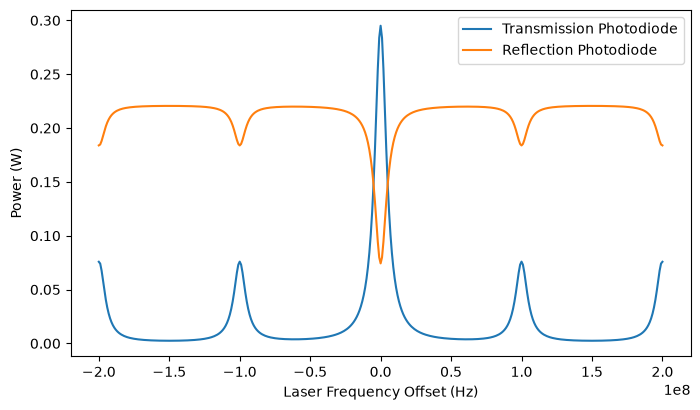

In [53]:
# Plotting frequency sweep
onetone.parse("xaxis(laser.f, lin, -200M, 200M, 400)")

# Run the model and create x data array
sol = onetone.run()
solxdata = np.squeeze(sol.x)  # squeeze cuts out a 1 entry array element that appears to exist to make our lives difficult

plt.figure(figsize=(8,4.5))
plt.plot(solxdata, sol["pdtrans"], label="Transmission Photodiode")
plt.plot(solxdata, sol["pdrefl"], label="Reflection Photodiode")
plt.xlabel("Laser Frequency Offset (Hz)")
plt.ylabel("Power (W)")
plt.legend(loc = "upper right")


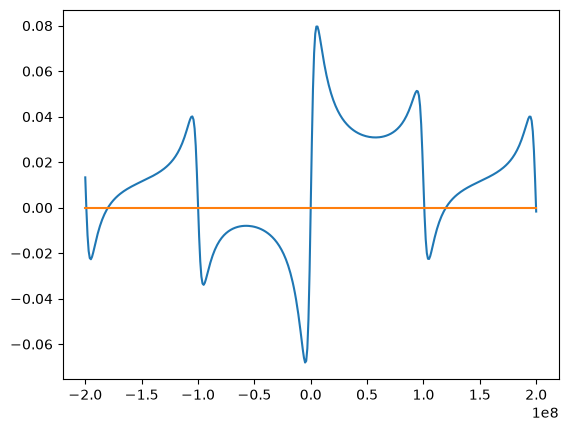

In [54]:
plt.plot(solxdata, sol["pdh"])
plt.plot(solxdata,np.zeros(len(solxdata)))
plt.show()

In [67]:
twotone = model.deepcopy()
# script = twotone.unparse()
# lines = [l for l in script.splitlines() if "am1.p2" not in l or "bs1.p1" not in l]
# twotone = finesse.Model()
# twotone.parse("\n".join(lines))
twotone.parse("""
    mod pm2 25M 0.9 order=1 mod_type=pm phase=0.0
    mod am2 25M 0.1 order=1 mod_type=am phase=0.0
    
    link(laser,pm1,am1,pm2,am2,bs1,inm)
""")

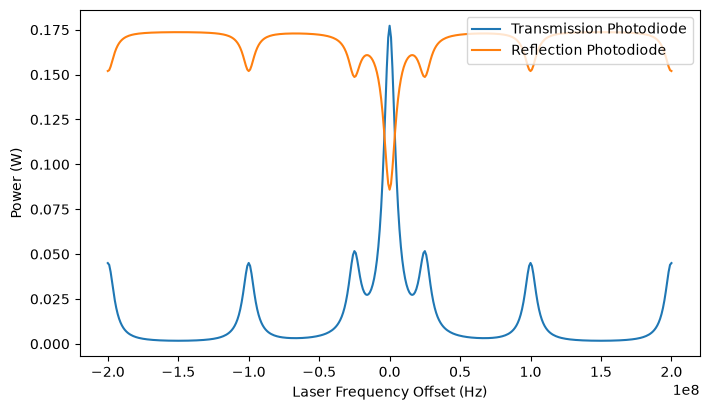

In [68]:
twotone.parse("xaxis(laser.f, lin, -200M, 200M, 400)")

sol2tone = twotone.run()
sol2tonexdata = np.squeeze(sol2tone.x)

plt.figure(figsize=(8,4.5))
plt.plot(sol2tonexdata, sol2tone["pdtrans"], label="Transmission Photodiode")
plt.plot(sol2tonexdata, sol2tone["pdrefl"], label="Reflection Photodiode")
plt.xlabel("Laser Frequency Offset (Hz)")
plt.ylabel("Power (W)")
plt.legend(loc = "upper right")

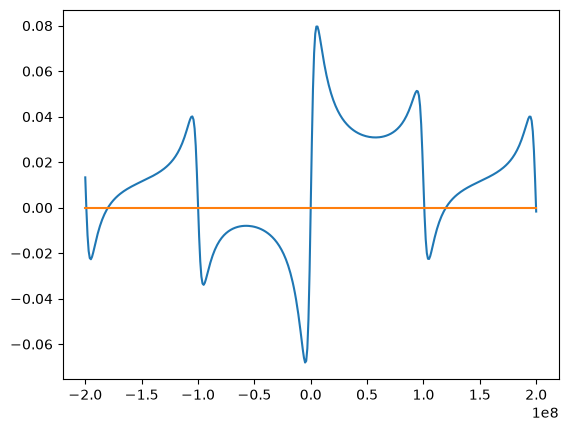

In [69]:
plt.plot(sol2tonexdata, sol["pdh"])
plt.plot(sol2tonexdata,np.zeros(len(sol2tonexdata)))
plt.show()